<a href="https://colab.research.google.com/github/Joaoplims/sna_roblox_kg/blob/main/Roblox_KG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install requests

## SETUP

In [2]:
from google.colab import userdata

API_KEY = userdata.get('roblox_oauth')
HEADERS = {
    "x-api-key": API_KEY,
    "Content-Type": "application/json"
}

## Utilidades

In [3]:
def save_df_to_csv(df, filename="data_export.csv"):
    """
    Salva um DataFrame do pandas em um arquivo CSV.
    """
    try:
        df.to_csv(filename, index=False, encoding='utf-8-sig')
        print(f"✅ Arquivo '{filename}' salvo com sucesso!")
    except Exception as e:
        print(f"❌ Erro ao salvar o arquivo: {e}")

# Exemplo de uso com os dados processados anteriormente:
# save_df_to_csv(df_users, "usuarios_roblox.csv")

## Função de Chamada para a API

In [4]:
import requests
import time
import random

def make_roblox_request(url, method="GET", params=None, data=None, max_retries=5, auto_paginate=False):
    """
    Função genérica para realizar chamadas à API do Roblox com suporte a Rate Limiting e Paginação.
    """
    all_data = []
    current_params = params.copy() if params else {}

    while True:
        retry_count = 0
        success = False

        while retry_count <= max_retries:
            try:
                response = requests.request(
                    method=method,
                    url=url,
                    headers=HEADERS,
                    params=current_params,
                    json=data
                )

                if response.status_code == 200:
                    res_json = response.json()

                    # Lógica de detecção: se houver uma chave 'data' e for uma lista, tratamos como paginável
                    if isinstance(res_json, dict) and 'data' in res_json and isinstance(res_json['data'], list):
                        page_items = res_json['data']
                        all_data.extend(page_items)

                        next_cursor = res_json.get('nextPageCursor')
                        if auto_paginate and next_cursor:
                            current_params['cursor'] = next_cursor
                            print(f"📄 Página processada. Buscando próxima página...")
                            success = True
                            break
                        else:
                            print(f"✅ Sucesso [{method}]: {url} (Total itens: {len(all_data)})")
                            return {"data": all_data}
                    else:
                        # Se não for uma lista paginável, retorna o JSON bruto (caso da Cloud API v2)
                        print(f"✅ Sucesso [{method}]: {url} (Objeto individual)")
                        return res_json

                elif response.status_code == 429:
                    retry_count += 1
                    wait_time = int(response.headers.get("retry-after", (2 ** retry_count) + random.uniform(0, 1)))
                    print(f"⚠️ Rate Limited (429). Aguardando {wait_time}s...")
                    time.sleep(wait_time)
                    continue
                else:
                    print(f"❌ Erro {response.status_code}: {response.text}")
                    return None
            except Exception as e:
                print(f"❌ Erro na requisição: {e}")
                return None

        if not success: break
    return None

## Teste chamadas


In [ ]:
target_uid = 947838656
user_api_url = f"https://apis.roblox.com/cloud/v2/users/{target_uid}"

print(f"📡 Consultando dados para o usuário: {target_uid}...")
user_data_response = make_roblox_request(user_api_url)

import json
if user_data_response:
    print("✅ Resposta recebida:")
    print(json.dumps(user_data_response, indent=4))
else:
    print("❌ Não foi possível obter os dados do usuário.")

📡 Consultando dados para o usuário: 947838656...
✅ Sucesso [GET]: https://apis.roblox.com/cloud/v2/users/947838656 (Objeto individual)
✅ Resposta recebida:
{
    "path": "users/947838656",
    "createTime": "2019-01-28T20:56:39.770Z",
    "id": "947838656",
    "name": "Scriptbloxian",
    "displayName": "Scriptbloxian",
    "about": "Lead Developer of Scriptbloxian Studios\nhttps://www.roblox.com/groups/4705120/Scriptbloxian-Studios",
    "locale": "en_us",
    "premium": true
}


In [ ]:
import requests
import json

# Teste direto sem a função make_roblox_request
test_uid = 947838656
test_url = f"https://apis.roblox.com/cloud/v2/users/{test_uid}"

print(f"📡 Teste Direto (requests): {test_url}")
test_response = requests.get(test_url, headers=HEADERS)

print(f"Status Code: {test_response.status_code}")
try:
    raw_json = test_response.json()
    print("Raw JSON Response:")
    print(json.dumps(raw_json, indent=4))
except Exception as e:
    print(f"Erro ao decodificar JSON: {e}")
    print(f"Conteúdo bruto: {test_response.text}")

📡 Teste Direto (requests): https://apis.roblox.com/cloud/v2/users/947838656
Status Code: 200
Raw JSON Response:
{
    "path": "users/947838656",
    "createTime": "2019-01-28T20:56:39.770Z",
    "id": "947838656",
    "name": "Scriptbloxian",
    "displayName": "Scriptbloxian",
    "about": "Lead Developer of Scriptbloxian Studios\nhttps://www.roblox.com/groups/4705120/Scriptbloxian-Studios",
    "locale": "en_us",
    "premium": true
}


## Encontrar ID Seed Group

In [5]:
import time
# Cache do id do grupo mais popular (Scriptbloxian Studios) para evitar chamadas excessiva
ID_SEED_GROUP = 0
# Buscar o Grupo 'Scriptbloxian Studios'
# Pesquisas indicam que é um dos grupos mais populares (https://roblox.fandom.com/pt-br/wiki/Scriptbloxian_Studios)
# Grupo de desenvolvedor de jogos famoso
group_search_url = "https://groups.roblox.com/v1/groups/search/lookup?groupName=Scriptbloxian%20Studios"
group_search_results = make_roblox_request(group_search_url)

if group_search_results and group_search_results.get('data'):
    group_info = group_search_results['data'][0]
    group_id = group_info['id']
    ID_SEED_GROUP = group_id
    print(f"🎯 Grupo Encontrado: {group_info['name']} (ID: {group_id})")
else:
    print("❌ Grupo não encontrado ou erro na busca.")

✅ Sucesso [GET]: https://groups.roblox.com/v1/groups/search/lookup?groupName=Scriptbloxian%20Studios (Total itens: 10)
🎯 Grupo Encontrado: Scriptbloxian Studios (ID: 4705120)


## Consulta de usuários

In [6]:
SAMPLE_SIZE = 25  # Parametrizável

# 2. Extrair membros do grupo semente
members_url = f"https://groups.roblox.com/v1/groups/{ID_SEED_GROUP}/users?sortOrder=Asc&limit={SAMPLE_SIZE}"
members_data = make_roblox_request(members_url, auto_paginate = False)

user_ids = []
if members_data and 'data' in members_data:
    user_ids = [member['user']['userId'] for member in members_data['data']]
    print(f"👥 Extraídos {len(user_ids)} usuários do grupo semente (ID: {ID_SEED_GROUP}).")
    print(f"Amostra de IDs: {user_ids}")
else:
    print("❌ Não foi possível extrair os membros do grupo.")

✅ Sucesso [GET]: https://groups.roblox.com/v1/groups/4705120/users?sortOrder=Asc&limit=25 (Total itens: 25)
👥 Extraídos 25 usuários do grupo semente (ID: 4705120).
Amostra de IDs: [947838656, 1027961385, 357829182, 244267273, 740396998, 731822913, 871184693, 262953699, 940534557, 970378427, 386824609, 747056849, 452079889, 519533783, 174791020, 363117394, 1041550312, 1038182669, 727787047, 557051148, 1023552809, 112492866, 363983769, 1014686408, 726703596]


### Processamento de Dados dos Usuários
Nesta etapa, consultamos a API de Usuários da Cloud API para obter detalhes como `createTime` e `locale`, calculando métricas derivadas.

In [ ]:
from datetime import datetime, timezone
import pandas as pd
import time

processed_users = []
now = datetime.now(timezone.utc)

print(f"🔍 Processando {len(user_ids)} usuários...\n")

for uid in user_ids:
    url = f"https://apis.roblox.com/cloud/v2/users/{uid}"
    # A função corrigida agora retorna o objeto diretamente para a Cloud API v2
    user_data = make_roblox_request(url, auto_paginate=False)

    if user_data and user_data.get('createTime'):
        create_time_str = user_data['createTime']
        create_time_dt = datetime.fromisoformat(create_time_str.replace('Z', '+00:00'))

        delta = now - create_time_dt
        age = delta.days / 365.25

        processed_users.append({
            "user_id": user_data.get('id'),
            "display_name": user_data.get('displayName'),
            "created_at": create_time_str,
            "age_years": round(age, 2),
            "level": "Veterano" if age >= 10 else "Intermediário" if age >= 4 else "Iniciante"
        })
    else:
        print(f"⚠️ Falha ao obter detalhes do usuário {uid}")

    time.sleep(0.2)

df_users = pd.DataFrame(processed_users)
if not df_users.empty:
    display(df_users.head(10))
else:
    print("❌ Nenhum dado processado.")

🔍 Processando 25 usuários...

✅ Sucesso [GET]: https://apis.roblox.com/cloud/v2/users/947838656 (Objeto individual)
✅ Sucesso [GET]: https://apis.roblox.com/cloud/v2/users/1027961385 (Objeto individual)
✅ Sucesso [GET]: https://apis.roblox.com/cloud/v2/users/357829182 (Objeto individual)
✅ Sucesso [GET]: https://apis.roblox.com/cloud/v2/users/244267273 (Objeto individual)
✅ Sucesso [GET]: https://apis.roblox.com/cloud/v2/users/740396998 (Objeto individual)
✅ Sucesso [GET]: https://apis.roblox.com/cloud/v2/users/731822913 (Objeto individual)
✅ Sucesso [GET]: https://apis.roblox.com/cloud/v2/users/871184693 (Objeto individual)
✅ Sucesso [GET]: https://apis.roblox.com/cloud/v2/users/262953699 (Objeto individual)
✅ Sucesso [GET]: https://apis.roblox.com/cloud/v2/users/940534557 (Objeto individual)
✅ Sucesso [GET]: https://apis.roblox.com/cloud/v2/users/970378427 (Objeto individual)
✅ Sucesso [GET]: https://apis.roblox.com/cloud/v2/users/386824609 (Objeto individual)
✅ Sucesso [GET]: https:

,user_id,display_name,created_at,age_years,level
0,947838656,Scriptbloxian,2019-01-28T20:56:39.770Z,7.55,Intermediário
1,1027961385,Iamsmarterthanyahya3,2019-04-04T20:14:50.953Z,7.37,Intermediário
2,357829182,FallenGh,2017-08-02T17:39:17.880Z,9.04,Intermediário
3,244267273,kidsgivemesloppy,2017-02-20T05:17:52.727Z,9.49,Intermediário
4,740396998,Lloyd,2018-08-30T19:34:01.370Z,7.96,Intermediário
5,731822913,Kirill_pro300,2018-08-26T16:09:21.050Z,7.98,Intermediário
6,871184693,hunika201,2018-11-24T09:20:23.383Z,7.73,Intermediário
7,262953699,kevin2598,2017-03-14T15:33:27.687Z,9.43,Intermediário
8,940534557,furiouse_2,2019-01-23T01:56:45.160Z,7.57,Intermediário
9,970378427,Mid_Bacon,2019-02-16T16:54:47.510Z,7.50,Intermediário


### Exportação de Dados
Salvando o conjunto de dados processado em um arquivo CSV para uso externo.

In [ ]:
# Exportando os usuários processados
save_df_to_csv(df_users, "usuarios_roblox_processados.csv")

✅ Arquivo 'usuarios_roblox_processados.csv' salvo com sucesso!


## First Hop

### Mapeamento de Afiliações (First Hop)
Nesta etapa, buscamos todos os grupos de cada um dos usuários da nossa amostra inicial para descobrir as conexões entre eles.

In [ ]:
graph_edges = []

print(f"🕸️ Iniciando mapeamento de afiliações para {len(user_ids)} usuários...")

for uid in user_ids:
    # Buscar metadados do usuário já processados no df_users
    user_meta = df_users[df_users['user_id'] == str(uid)]
    user_age = user_meta['age_years'].values[0] if not user_meta.empty else None
    user_level = user_meta['level'].values[0] if not user_meta.empty else "Desconhecido"

    # Endpoint da API V1 para listar grupos/cargos do usuário
    affiliations_url = f"https://groups.roblox.com/v1/users/{uid}/groups/roles"

    # Realiza a chamada
    response = make_roblox_request(affiliations_url, auto_paginate=False)

    if response and 'data' in response:
        groups = response['data']
        for item in groups:
            group_info = item.get('group', {})
            role_info = item.get('role', {})

            # Registramos a aresta enriquecida com dados do usuário
            edge = {
                "source_id": uid,
                "source_type": "User",
                "source_age_years": user_age,
                "source_level": user_level,
                "target_id": group_info.get('id'),
                "target_name": group_info.get('name'),
                "target_type": "Group",
                "role_name": role_info.get('name'),
                "role_rank": role_info.get('rank')
            }
            graph_edges.append(edge)

    # Pequeno delay para respeitar a API
    time.sleep(0.2)

# Criando um DataFrame para visualizar as conexões
df_graph = pd.DataFrame(graph_edges)
print(f"✅ Mapeamento concluído! Encontradas {len(df_graph)} conexões enriquecidas.")
display(df_graph.head(10))

🕸️ Iniciando mapeamento de afiliações para 25 usuários...
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/947838656/groups/roles (Total itens: 9)
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/1027961385/groups/roles (Total itens: 1)
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/357829182/groups/roles (Total itens: 28)
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/244267273/groups/roles (Total itens: 14)
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/740396998/groups/roles (Total itens: 27)
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/731822913/groups/roles (Total itens: 4)
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/871184693/groups/roles (Total itens: 4)
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/262953699/groups/roles (Total itens: 5)
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/940534557/groups/roles (Total itens: 3)
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/970378427/groups/roles (Total itens: 6)
✅ Sucesso [GET]: h

,source_id,source_type,source_age_years,source_level,target_id,target_name,target_type,role_name,role_rank
0,947838656,User,7.55,Intermediário,257737430,Mischief Mechanics,Group,Owner,255
1,947838656,User,7.55,Intermediário,10975897,XP Games.,Group,[D] Developer,253
2,947838656,User,7.55,Intermediário,32794027,Titan Trainers,Group,Admin,254
3,947838656,User,7.55,Intermediário,32073904,Hero Rivals Arena,Group,Owner,255
4,947838656,User,7.55,Intermediário,16345189,Super Slide,Group,Owner,255
5,947838656,User,7.55,Intermediário,16176597,Shinoro Studios,Group,Owner,255
6,947838656,User,7.55,Intermediário,16170756,Magnetworks,Group,Owner,255
7,947838656,User,7.55,Intermediário,11979111,Scriptbloxian Creation Group,Group,Owner,255
8,947838656,User,7.55,Intermediário,4705120,Scriptbloxian Studios,Group,Lead Developer,255
9,1027961385,User,7.37,Intermediário,4705120,Scriptbloxian Studios,Group,Legend,1


In [ ]:
# Exibindo uma amostra das arestas criadas
if graph_edges:
    print("Amostra das conexões:")
    for edge in graph_edges:
        print(f"Usuário [{edge['source_id']}], de nível [{edge['source_level']}] participando do Grupo [{edge['target_name']}] como '{edge['role_name']}' (Rank: {edge['role_rank']})")
else:
    print("❌ Nenhuma aresta encontrada")

Amostra das conexões:
Usuário [947838656], de nível [Intermediário] participando do Grupo [Mischief Mechanics] como 'Owner' (Rank: 255)
Usuário [947838656], de nível [Intermediário] participando do Grupo [XP Games.] como '[D] Developer' (Rank: 253)
Usuário [947838656], de nível [Intermediário] participando do Grupo [Titan Trainers] como 'Admin' (Rank: 254)
Usuário [947838656], de nível [Intermediário] participando do Grupo [Hero Rivals Arena] como 'Owner' (Rank: 255)
Usuário [947838656], de nível [Intermediário] participando do Grupo [Super Slide] como 'Owner' (Rank: 255)
Usuário [947838656], de nível [Intermediário] participando do Grupo [Shinoro Studios] como 'Owner' (Rank: 255)
Usuário [947838656], de nível [Intermediário] participando do Grupo [Magnetworks] como 'Owner' (Rank: 255)
Usuário [947838656], de nível [Intermediário] participando do Grupo [Scriptbloxian Creation Group] como 'Owner' (Rank: 255)
Usuário [947838656], de nível [Intermediário] participando do Grupo [Scriptblox

In [ ]:
# Salvar o progresso do grafo
save_df_to_csv(df_graph, "conexoes_roblox_first_hop.csv")

✅ Arquivo 'conexoes_roblox_first_hop.csv' salvo com sucesso!


### Análise da Distribuição de Ranks
Nesta seção, visualizamos como os ranks (cargos) estão distribuídos nas conexões coletadas. Ranks mais altos (ex: 255) geralmente indicam donos ou administradores, enquanto ranks baixos (ex: 1) indicam membros comuns.

In [ ]:
import pandas as pd

# Calculando a contagem absoluta
distribuicao = df_graph['role_rank'].value_counts().sort_index(ascending=False).reset_index()
distribuicao.columns = ['Role Rank', 'Quantidade']

# Calculando a porcentagem
distribuicao['Percentual (%)'] = (distribuicao['Quantidade'] / distribuicao['Quantidade'].sum() * 100).round(2)

# Exibindo a tabela completa
display(distribuicao)

,Role Rank,Quantidade,Percentual (%)
0,255,9,2.27
1,254,1,0.25
2,253,1,0.25
3,245,1,0.25
4,244,1,0.25
5,154,1,0.25
6,150,3,0.76
7,30,1,0.25
8,10,4,1.01
9,7,1,0.25


## Second Hop

In [ ]:
# Extraindo os IDs de grupos únicos (target_id) do DataFrame de conexões
unique_group_ids = df_graph['target_id'].unique().tolist()

print(f"🔍 Total de conexões: {len(df_graph)}")
print(f"🎯 Total de grupos únicos identificados: {len(unique_group_ids)}")
print(f"Amostra dos IDs: {unique_group_ids[:10]}")

🔍 Total de conexões: 397
🎯 Total de grupos únicos identificados: 299
Amostra dos IDs: [257737430, 10975897, 32794027, 32073904, 16345189, 16176597, 16170756, 11979111, 4705120, 34990762]


### Coleta de Membros por Grupo (Second Hop)
Nesta etapa, para cada grupo mapeado anteriormente, solicitamos a lista de membros (limitada aos 20 primeiros) para construir a rede de conexões de segundo nível.

In [ ]:
second_hop_edges = []


print(f"🚀 Iniciando coleta de membros para {len(unique_group_ids)} grupos...")

for i, group_id in enumerate(unique_group_ids):
    # Progresso a cada 20 grupos para não poluir o console
    if i % 20 == 0:
        print(f"📦 Processando grupo {i}/{len(unique_group_ids)}...")

    # Endpoint para listar membros do grupo
    members_url = f"https://groups.roblox.com/v1/groups/{group_id}/users?sortOrder=Asc&limit={SAMPLE_SIZE}"

    response = make_roblox_request(members_url, auto_paginate=False)

    if response and 'data' in response:
        for member in response['data']:
            user_info = member.get('user', {})
            role_info = member.get('role', {})

            second_hop_edges.append({
                "source_id": user_info.get('userId'),
                "source_name": user_info.get('username'),
                "source_type": "User",
                "target_id": group_id,
                "target_type": "Group",
                "role_name": role_info.get('name'),
                "role_rank": role_info.get('rank')
            })

    # Delay para evitar 429 (Rate Limit)
    time.sleep(0.1)

df_second_hop = pd.DataFrame(second_hop_edges)
print(f"\n✅ Coleta concluída!")
print(f"Total de novas conexões encontradas: {len(df_second_hop)}")
display(df_second_hop.head(10))

🚀 Iniciando coleta de membros para 299 grupos...
📦 Processando grupo 0/299...
❌ Erro 400: {"errors":[{"code":3,"message":"The user is invalid or does not exist.","userFacingMessage":"The user is invalid or does not exist."}]}
✅ Sucesso [GET]: https://groups.roblox.com/v1/groups/10975897/users?sortOrder=Asc&limit=25 (Total itens: 25)
✅ Sucesso [GET]: https://groups.roblox.com/v1/groups/32794027/users?sortOrder=Asc&limit=25 (Total itens: 25)
✅ Sucesso [GET]: https://groups.roblox.com/v1/groups/32073904/users?sortOrder=Asc&limit=25 (Total itens: 1)
✅ Sucesso [GET]: https://groups.roblox.com/v1/groups/16345189/users?sortOrder=Asc&limit=25 (Total itens: 4)
✅ Sucesso [GET]: https://groups.roblox.com/v1/groups/16176597/users?sortOrder=Asc&limit=25 (Total itens: 6)
✅ Sucesso [GET]: https://groups.roblox.com/v1/groups/16170756/users?sortOrder=Asc&limit=25 (Total itens: 1)
✅ Sucesso [GET]: https://groups.roblox.com/v1/groups/11979111/users?sortOrder=Asc&limit=25 (Total itens: 10)
✅ Sucesso [GET]

,source_id,source_name,source_type,target_id,target_type,role_name,role_rank
0,1711299025,PrincessRayn44,User,10975897,Group,[G] Gamer,1
1,2558399989,Izzybotyourgot,User,10975897,Group,[G] Gamer,1
2,2591680131,batmankian900,User,10975897,Group,[G] Gamer,1
3,2489593516,lonzell_9,User,10975897,Group,[G] Gamer,1
4,2335800629,WDGanns,User,10975897,Group,[G] Gamer,1
5,2560085628,joew5709,User,10975897,Group,[G] Gamer,1
6,2634340174,RICHIE1448,User,10975897,Group,[G] Gamer,1
7,14358363,xEmberz,User,10975897,Group,[G] Gamer,1
8,2339442932,Toenailskidnoob,User,10975897,Group,[G] Gamer,1
9,1469500187,dkdkjekdndn,User,10975897,Group,[G] Gamer,1


In [ ]:
# Salvando o resultado do segundo salto
save_df_to_csv(df_second_hop, "conexoes_roblox_second_hop.csv")

✅ Arquivo 'conexoes_roblox_second_hop.csv' salvo com sucesso!


In [ ]:
from google.colab import drive
import os
import time
from datetime import datetime, timezone
import pandas as pd

# Função auxiliar para salvar com segurança contra erros de I/O do Drive
def safe_save_csv(df, path):
    try:
        df.to_csv(path, index=False)
        print(f"💾 Arquivo salvo com sucesso: {path}")
    except OSError as e:
        if e.errno == 5: # Input/output error
            print("⚠️ Erro de I/O detectado. Tentando remontar o Google Drive...")
            drive.mount('/content/drive', force_remount=True)
            df.to_csv(path, index=False)
            print("✅ Salvo após remontar o drive.")
        else:
            print(f"❌ Erro ao salvar: {e}")

# 1. Montar o Drive
drive.mount('/content/drive')
save_path = '/content/drive/My Drive/roblox_graph_data/'
os.makedirs(save_path, exist_ok=True)

# 2. Remover duplicatas
df_second_hop = df_second_hop.drop_duplicates(subset=['source_id', 'target_id'])
print(f"✅ Duplicatas removidas. Total: {len(df_second_hop)}")

# 3. Mapeamento
new_user_ids = df_second_hop['source_id'].unique().tolist()
second_hop_affiliations = []
now = datetime.now(timezone.utc)

print(f"🕸️ Mapeando {len(new_user_ids)} usuários...")

for i, uid in enumerate(new_user_ids):
    user_api_url = f"https://apis.roblox.com/cloud/v2/users/{uid}"
    user_data = make_roblox_request(user_api_url, auto_paginate=False)

    user_age = None
    user_level = "Desconhecido"

    if user_data and user_data.get('createTime'):
        create_time_str = user_data['createTime']
        create_time_dt = datetime.fromisoformat(create_time_str.replace('Z', '+00:00'))
        delta = now - create_time_dt
        user_age = round(delta.days / 365.25, 2)
        user_level = "Veterano" if user_age >= 7 else "Intermediário" if user_age >= 2 else "Iniciante"

    affiliations_url = f"https://groups.roblox.com/v1/users/{uid}/groups/roles"
    response = make_roblox_request(affiliations_url, auto_paginate=False)

    if response and 'data' in response:
        for item in response['data']:
            group_info = item.get('group', {})
            role_info = item.get('role', {})
            second_hop_affiliations.append({
                "source_id": uid,
                "source_account_age_years": user_age,
                "source_level": user_level,
                "target_id": group_info.get('id'),
                "target_name": group_info.get('name'),
                "role_name": role_info.get('name'),
                "role_rank": role_info.get('rank')
            })

    # Checkpoint seguro
    if (i + 1) % 200 == 0:
        temp_df = pd.DataFrame(second_hop_affiliations)
        safe_save_csv(temp_df, f"{save_path}checkpoint_batch_{i+1}.csv")

    time.sleep(0.3)

df_expanded_graph = pd.DataFrame(second_hop_affiliations)
safe_save_csv(df_expanded_graph, f"{save_path}full_second_hop_affiliations_enriched.csv")
display(df_expanded_graph.head())

A saída de streaming foi truncada nas últimas 5000 linhas.
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/235467363/groups/roles (Total itens: 36)
❌ Erro 404: { "code": "NOT_FOUND", "message": "User not found." }
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/170940120/groups/roles (Total itens: 24)
✅ Sucesso [GET]: https://apis.roblox.com/cloud/v2/users/213096355 (Objeto individual)
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/213096355/groups/roles (Total itens: 68)
✅ Sucesso [GET]: https://apis.roblox.com/cloud/v2/users/641315869 (Objeto individual)
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/641315869/groups/roles (Total itens: 36)
❌ Erro 404: { "code": "NOT_FOUND", "message": "User not found." }
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/254549886/groups/roles (Total itens: 10)
✅ Sucesso [GET]: https://apis.roblox.com/cloud/v2/users/332410276 (Objeto individual)
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/332410276/groups/roles (Total iten

,source_id,source_account_age_years,source_level,target_id,target_name,role_name,role_rank
0,1711299025,6.15,Intermediário,13420266,PLANETERIUM,⭐ Player,1
1,1711299025,6.15,Intermediário,35669818,크롱 스튜디오,멤버,1
2,1711299025,6.15,Intermediário,393625465,Anime Slap Tower,Member,1
3,1711299025,6.15,Intermediário,33092455,HAKI SHOP,🦋Member,2
4,1711299025,6.15,Intermediário,16805444,Denis dave,Member,1


## Montagem Knowladge Graph

In [7]:
import pandas as pd
import networkx as nx

# 1. Carregar o arquivo enriquecido
file_name = "full_second_hop_affiliations_enriched.csv"
df_enriched = pd.read_csv(file_name)

# 2. Instanciar o grafo direcionado
G = nx.DiGraph()

print(f"🏗️ Construindo grafo a partir de {len(df_enriched)} conexões...")

# 3. Construção com Desacoplamento de Atributos
for row in df_enriched.itertuples(index=False):
    user_node = f"U_{row.source_id}"
    group_node = f"G_{row.target_id}"

    # Aloca as propriedades intrínsecas ao nó do Usuário (Vulnerabilidade)
    G.add_node(
        user_node,
        type='User',
        label=row.source_id,
        account_age_years=row.source_account_age_years,
        level=row.source_level
    )

    # Aloca as propriedades intrínsecas ao nó do Grupo
    G.add_node(
        group_node,
        type='Group',
        name=row.target_name,
        label=row.target_id
    )

    # Cria a aresta mantendo os dados brutos de hierarquia
    G.add_edge(
        user_node,
        group_node,
        role=row.role_name,
        rank=row.role_rank
    )

print("✅ Grafo de Conhecimento instanciado com semântica completa!")

🏗️ Construindo grafo a partir de 266987 conexões...
✅ Grafo de Conhecimento instanciado com semântica completa!


In [8]:
import networkx as nx
import re

print("Iniciando limpeza de caracteres incompatíveis com XML...")

# Regex para detectar caracteres de controle invisíveis e bytes nulos que quebram o XML
# Mantém letras, números, símbolos, espaços e até a maioria dos emojis intactos
illegal_xml_chars_re = re.compile(r'[\x00-\x08\x0b\x0c\x0e-\x1F\uD800-\uDFFF\uFFFE\uFFFF]')

def sanitize_string(valor):
    """Limpa a string se for texto; se for número, retorna intacto."""
    if isinstance(valor, str):
        return illegal_xml_chars_re.sub('', valor)
    return valor

# 1. Limpar os atributos de todos os Nós (User e Group)
for n, data in G.nodes(data=True):
    for chave, valor in data.items():
        data[chave] = sanitize_string(valor)

# 2. Limpar os atributos de todas as Arestas
for u, v, data in G.edges(data=True):
    for chave, valor in data.items():
        data[chave] = sanitize_string(valor)

print("Limpeza concluída! Tentando exportar novamente...")

# 3. Exportar para GraphML
nome_arquivo_exportacao = "knowledge_graph_roblox_completo.graphml"

try:
    nx.write_graphml(G, nome_arquivo_exportacao)
    print(f"✅ Sucesso! O grafo foi exportado e salvo como: {nome_arquivo_exportacao}")
    print("Agora você pode baixar o arquivo e abri-lo no Gephi.")
except Exception as e:
    print(f"❌ Ocorreu um novo erro durante a exportação: {e}")

Iniciando limpeza de caracteres incompatíveis com XML...
Limpeza concluída! Tentando exportar novamente...
✅ Sucesso! O grafo foi exportado e salvo como: knowledge_graph_roblox_completo.graphml
Agora você pode baixar o arquivo e abri-lo no Gephi.


In [ ]:
import networkx as nx

# Exporta o grafo da memória para o formato GraphML
nome_arquivo_exportacao = "knowledge_graph_roblox_completo.graphml"

print(f"Exportando o grafo para {nome_arquivo_exportacao}...")
nx.write_graphml(G, nome_arquivo_exportacao)
print("Exportação concluída! Baixe o arquivo e abra no Gephi.")

Exportando o grafo para knowledge_graph_roblox_completo.graphml...
Exportação concluída! Baixe o arquivo e abra no Gephi.


## Analises da Rede Social

### Análise de Projeção 1-Mode (Usuário-Usuário)
Para realizar a análise de correlação indireta entre os usuários, projetei o grafo bipartido original em uma rede de Usuário-Usuário.

Nesta projeção, dois usuários são conectados se compartilharem ao menos um grupo no Roblox.

In [11]:
import networkx as nx

# Identificar nós de usuários e grupos
user_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'User']
group_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'Group']

print(f"📊 Analisando correlações entre {len(user_nodes)} usuários em {len(group_nodes)} grupos...")

count = 0
max_display = 15

print("\n🔍 Detalhamento das Correlações Indiretas:")

# Iterar sobre os grupos para encontrar usuários que compartilham o mesmo grupo
for g_node in group_nodes:
    if count >= max_display: break

    # No Grafo direcionado (DiGraph), os usuários apontam para os grupos (U -> G)
    # Então buscamos os predecessores do nó do grupo
    members = list(G.predecessors(g_node))

    if len(members) > 1:
        # Se houver mais de um usuário, eles possuem uma correlação indireta
        group_data = G.nodes[g_node]

        # Pegamos pares de usuários no grupo para exemplificar a correlação
        for i in range(len(members)):
            if count >= max_display: break
            u = members[i]
            for j in range(i + 1, len(members)):
                if count >= max_display: break
                v = members[j]

                u_data = G.nodes[u]
                u_edge = G.get_edge_data(u, g_node)
                v_id = G.nodes[v].get('label')

                # Print conforme o formato solicitado pelo usuário
                print(f"O usuário {u_data.get('label')}, membro da {group_data.get('name')} como {u_edge.get('role')}, "
                      f"possui correlação indireta com o usuário {v_id} através deste grupo (Nível: {u_data.get('source_level', u_data.get('level'))}).")

                count += 1

if count == 0:
    print("⚠️ Nenhuma correlação indireta encontrada na amostra atual.")

📊 Analisando correlações entre 6729 usuários em 66160 grupos...

🔍 Detalhamento das Correlações Indiretas:
O usuário 1711299025, membro da PLANETERIUM como ⭐ Player, possui correlação indireta com o usuário 575054621 através deste grupo (Nível: Intermediário).
O usuário 1711299025, membro da PLANETERIUM como ⭐ Player, possui correlação indireta com o usuário 1221592026 através deste grupo (Nível: Intermediário).
O usuário 575054621, membro da PLANETERIUM como ⭐ Player, possui correlação indireta com o usuário 1221592026 através deste grupo (Nível: Veterano).
O usuário 1711299025, membro da 크롱 스튜디오 como 멤버, possui correlação indireta com o usuário 4531635282 através deste grupo (Nível: Intermediário).
O usuário 1711299025, membro da 크롱 스튜디오 como 멤버, possui correlação indireta com o usuário 17897891 através deste grupo (Nível: Intermediário).
O usuário 1711299025, membro da 크롱 스튜디오 como 멤버, possui correlação indireta com o usuário 2258206473 através deste grupo (Nível: Intermediário).
O 

In [13]:
import networkx as nx
from itertools import combinations

# Identificar os nós de grupos
group_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'Group']
user_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'User']

print(f"📊 Analisando coparticipação entre {len(group_nodes)} grupos através de {len(user_nodes)} usuários...")

# Para otimizar, primeiro mapeamos quais usuários estão em quais grupos
shared_member_counts = []

# Limitamos a análise aos Top 2000 grupos para evitar processamento excessivo ou focamos nos que têm membros na amostra
# Vamos buscar grupos que possuem ao menos um predecessor (membro)
groups_with_members = [g for g in group_nodes if len(list(G.predecessors(g))) > 0]

# Dicionário de cache para membros
group_members_cache = {g: set(G.predecessors(g)) for g in groups_with_members}

# Comparar pares de grupos que compartilham usuários
# Para eficiência, iteramos sobre os usuários e vemos quais grupos eles conectam
user_to_groups = {u: list(G.successors(u)) for u in user_nodes}

from collections import Counter
group_pairs = Counter()

for u, groups in user_to_groups.items():
    if len(groups) > 1:
        for g1, g2 in combinations(sorted(groups), 2):
            group_pairs[(g1, g2)] += 1

# Formatar resultados
for (g1, g2), count in group_pairs.most_common(15):
    shared_member_counts.append({
        'group_a': G.nodes[g1].get('name', g1),
        'group_b': G.nodes[g2].get('name', g2),
        'shared_count': count
    })

print(f"✅ Análise concluída: {len(group_pairs)} pares de grupos compartilham membros.\n")

print("🔍 Matriz de Coparticipação - Top Grupos com Membros em Comum:")
for i, connection in enumerate(shared_member_counts):
    print(f"{i+1}. O grupo '{connection['group_a']}' compartilha {connection['shared_count']} membros com o grupo '{connection['group_b']}'.")

if not shared_member_counts:
    print("⚠️ Nenhuma sobreposição de membros encontrada entre os grupos na amostra atual.")

📊 Analisando coparticipação entre 66160 grupos através de 6729 usuários...
✅ Análise concluída: 7415890 pares de grupos compartilham membros.

🔍 Matriz de Coparticipação - Top Grupos com Membros em Comum:
1. O grupo 'Rumble Studios' compartilha 576 membros com o grupo 'Scriptbloxian Studios'.
2. O grupo 'BIG Games™' compartilha 566 membros com o grupo 'BIG Games Pets'.
3. O grupo 'Rumble Studios' compartilha 530 membros com o grupo 'BIG Games Pets'.
4. O grupo 'BIG Games Pets' compartilha 528 membros com o grupo 'Scriptbloxian Studios'.
5. O grupo 'Rumble Studios' compartilha 509 membros com o grupo 'Nosniy Games'.
6. O grupo 'Nosniy Games' compartilha 506 membros com o grupo 'Scriptbloxian Studios'.
7. O grupo 'Rumble Studios' compartilha 495 membros com o grupo 'Bee Swarm Simulator Club'.
8. O grupo 'BIG Games Pets' compartilha 457 membros com o grupo 'Bee Swarm Simulator Club'.
9. O grupo 'Bee Swarm Simulator Club' compartilha 447 membros com o grupo 'Scriptbloxian Studios'.
10. O g

### Centralidade de Grau do Usuário (Matriz de Coassociação $X_A$)
Nesta etapa, calculamos a centralidade baseada na soma das conexões na matriz de coassociação, identificando usuários com maior número de contatos indiretos via grupos compartilhados.

Na análise de redes sociais, esse usuário é considerado um 'hub' de informação, com um altíssimo potencial de influência e disseminação de conteúdo dentro da rede do Roblox.

In [14]:
import networkx as nx
import pandas as pd

# 1. Identificar nós de usuários e grupos
user_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'User']

# 2. Construir a métrica de centralidade baseada na Matriz de Coassociação X_A
# Para cada usuário, contamos quantos usuários únicos ele encontra em todos os seus grupos
user_degree_centrality = {}

print(f"🔢 Calculando centralidade para {len(user_nodes)} usuários...")

for u in user_nodes:
    # Grupos que o usuário 'u' participa
    groups = list(G.successors(u))

    # Outros usuários presentes nesses mesmos grupos (contatos da matriz X_A)
    neighbors = set()
    for g in groups:
        members = set(G.predecessors(g))
        neighbors.update(members)

    # Remove o próprio usuário da contagem de vizinhos
    neighbors.discard(u)
    user_degree_centrality[u] = len(neighbors)

# 3. Formatar resultados
centrality_results = []
for node, score in user_degree_centrality.items():
    node_data = G.nodes[node]
    centrality_results.append({
        "source_id": node_data.get('label'),
        "source_level": node_data.get('level'),
        "degree_centrality_score": score
    })

df_centrality = pd.DataFrame(centrality_results).sort_values(by='degree_centrality_score', ascending=False)

print("\n🏆 Top 10 Usuários por Centralidade de Grau (Contatos em X_A):")
display(df_centrality.head(10))

# Exemplo de print conforme solicitado anteriormente para o usuário mais central
if not df_centrality.empty:
    top_user = df_centrality.iloc[0]
    print(f"\nDestaque: O usuário {top_user['source_id']}, nível {top_user['source_level']}, possui {top_user['degree_centrality_score']} conexões únicas na rede de coassociação.")

🔢 Calculando centralidade para 6729 usuários...

🏆 Top 10 Usuários por Centralidade de Grau (Contatos em X_A):


,source_id,source_level,degree_centrality_score
84,363983769,Veterano,4710
1942,481845464,Veterano,4517
165,754766484,Veterano,4511
1399,196659367,Desconhecido,4483
1855,414281205,Veterano,4451
5928,1452692118,Intermediário,4381
2513,1760136846,Intermediário,4381
21,759872978,Veterano,4377
5353,1742730543,Intermediário,4376
5166,778605664,Veterano,4373



Destaque: O usuário 363983769, nível Veterano, possui 4710 conexões únicas na rede de coassociação.


### Centralidade de Grau do Grupo (Matriz de Coparticipação $X_E$)
Calculamos a centralidade para os grupos, medindo o total de conexões geradas pela sobreposição de membros com outros grupos da rede.

In [15]:
import pandas as pd

# 1. Identificar os nós de grupos
group_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'Group']

# 2. Calcular a Centralidade de Grau para cada grupo na rede de coparticipação
# A centralidade aqui é a soma dos 'pesos' (membros compartilhados) com outros grupos
group_centrality_results = []

print(f"🔢 Calculando centralidade para {len(group_nodes)} grupos...")

# Usando o dicionário group_pairs que calculamos na etapa da Matriz de Coparticipação
# group_pairs contém {(g1, g2): count}
group_scores = {}

for (g1, g2), count in group_pairs.items():
    group_scores[g1] = group_scores.get(g1, 0) + count
    group_scores[g2] = group_scores.get(g2, 0) + count

# 3. Formatar e exibir resultados
for g_node, score in group_scores.items():
    g_data = G.nodes[g_node]
    group_centrality_results.append({
        "target_id": g_data.get('label'),
        "target_name": g_data.get('name'),
        "group_degree_centrality": score
    })

df_group_centrality = pd.DataFrame(group_centrality_results).sort_values(by='group_degree_centrality', ascending=False)

print("\n🏆 Top 10 Grupos por Centralidade de Grau (Alcance em X_E):")
display(df_group_centrality.head(10))

if not df_group_centrality.empty:
    top_g = df_group_centrality.iloc[0]
    print(f"\nDestaque: O grupo '{top_g['target_name']}' (ID: {top_g['target_id']}) é o maior hub da rede, com um score de centralidade de {top_g['group_degree_centrality']}.")

🔢 Calculando centralidade para 66160 grupos...

🏆 Top 10 Grupos por Centralidade de Grau (Alcance em X_E):


,target_id,target_name,group_degree_centrality
148,4705120,Scriptbloxian Studios,91844
373,3461453,Nosniy Games,84621
140,3333298,Rumble Studios,84123
572,3959677,BIG Games Pets,80087
483,3982592,Bee Swarm Simulator Club,71619
975,2782840,Chillz Studios,68995
587,5522949,Powerful Studio,66056
1125,12836673,Wiggity.,62257
544,4914494,Paradoxum Games,57934
417,2703304,BIG Games™,57218



Destaque: O grupo 'Scriptbloxian Studios' (ID: 4705120) é o maior hub da rede, com um score de centralidade de 91844.


### Análise de Modelo Núcleo-Periferia Categorial
Nesta etapa, classificamos usuários e grupos em 'Núcleo' (Core) ou 'Periferia' (Periphery) com base em sua centralidade de grau. Um sistema núcleo-periferia é caracterizado por um subconjunto de nós altamente interconectados (core) e um conjunto de nós que se conectam ao núcleo, mas raramente entre si (periferia).

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir thresholds para o Núcleo (ex: top 10% mais centrais)
core_threshold_user = df_centrality['degree_centrality_score'].quantile(0.90)
core_threshold_group = df_group_centrality['group_degree_centrality'].quantile(0.90)

# 2. Identificar membros do Core e Periphery
core_users = set(df_centrality[df_centrality['degree_centrality_score'] >= core_threshold_user]['source_id'].astype(str))
core_groups = set(df_group_centrality[df_group_centrality['group_degree_centrality'] >= core_threshold_group]['target_id'].astype(str))

# 3. Mapear categorias no Grafo
for n, data in G.nodes(data=True):
    node_label = str(data.get('label'))
    if data.get('type') == 'User':
        data['cp_category'] = 'Core' if node_label in core_users else 'Periphery'
    else:
        data['cp_category'] = 'Core' if node_label in core_groups else 'Periphery'

print(f"👥 Usuários: {len(core_users)} no Core, {len(user_nodes) - len(core_users)} na Periferia")
print(f"🏢 Grupos: {len(core_groups)} no Core, {len(group_nodes) - len(core_groups)} na Periferia")

👥 Usuários: 674 no Core, 6055 na Periferia
🏢 Grupos: 6630 no Core, 59530 na Periferia


### Densidade dos Blocos
Agora, calculamos a densidade de conexões entre as quatro combinações possíveis: Core-Core, Core-Periphery, Periphery-Core e Periphery-Periphery para validar o modelo.

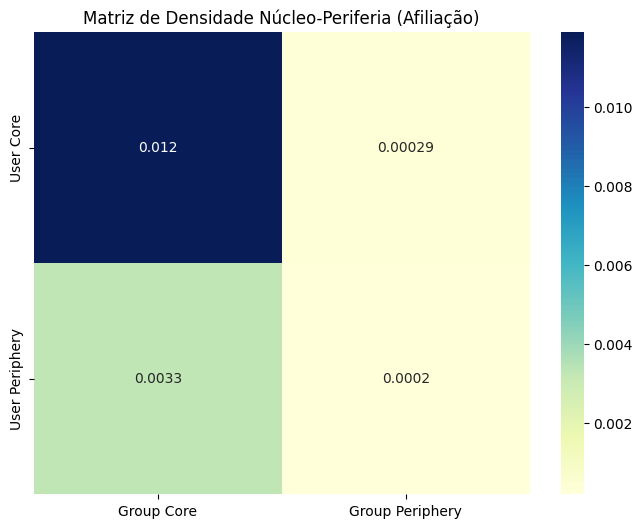


Interpretação: Um modelo ideal apresenta alta densidade no bloco Core-Core e baixa no Periphery-Periphery.


In [17]:
# 4. Calcular densidade por bloco
blocks = {'Core-Core': 0, 'Core-Periphery': 0, 'Periphery-Core': 0, 'Periphery-Periphery': 0}
counts = {'Core-Core': 0, 'Core-Periphery': 0, 'Periphery-Core': 0, 'Periphery-Periphery': 0}

# Filtrar nós por tipo e categoria
users_c = [n for n, d in G.nodes(data=True) if d.get('type') == 'User' and d.get('cp_category') == 'Core']
users_p = [n for n, d in G.nodes(data=True) if d.get('type') == 'User' and d.get('cp_category') == 'Periphery']
groups_c = [n for n, d in G.nodes(data=True) if d.get('type') == 'Group' and d.get('cp_category') == 'Core']
groups_p = [n for n, d in G.nodes(data=True) if d.get('type') == 'Group' and d.get('cp_category') == 'Periphery']

def get_block_density(sources, targets):
    if not sources or not targets: return 0
    edges_count = 0
    for s in sources:
        successors = set(G.successors(s))
        edges_count += len([t for t in targets if t in successors])
    return edges_count / (len(sources) * len(targets))

density_matrix = [
    [get_block_density(users_c, groups_c), get_block_density(users_c, groups_p)],
    [get_block_density(users_p, groups_c), get_block_density(users_p, groups_p)]
]

# 5. Visualização via Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(density_matrix, annot=True, cmap="YlGnBu",
            xticklabels=['Group Core', 'Group Periphery'],
            yticklabels=['User Core', 'User Periphery'])
plt.title("Matriz de Densidade Núcleo-Periferia (Afiliação)")
plt.show()

print("\nInterpretação: Um modelo ideal apresenta alta densidade no bloco Core-Core e baixa no Periphery-Periphery.")

### Densidade das Projeções ($D_A$ e $D_E$)
A densidade de uma projeção de 1 modo mede a conectividade geral.
- $D_A$: Densidade da rede de coassociação de usuários.
- $D_E$: Densidade da rede de coparticipação de grupos.

In [18]:
# 1. Densidade da Projeção de Usuários (D_A)
# O número de conexões possíveis em X_A é n*(n-1)/2
n_users = len(user_nodes)
possible_user_edges = (n_users * (n_users - 1)) / 2
actual_user_edges = len(df_centrality[df_centrality['degree_centrality_score'] > 0]) # Aproximação baseada em vizinhos únicos

# Como o cálculo exato de todas as arestas de X_A pode ser pesado, usamos a média das centralidades
d_a = df_centrality['degree_centrality_score'].mean() / (n_users - 1)

# 2. Densidade da Projeção de Grupos (D_E)
n_groups = len(group_nodes)
# d_e = total_edges_in_Xe / (n_groups * (n_groups - 1) / 2)
# Usando a média de centralidade de grupo calculada
d_e = df_group_centrality['group_degree_centrality'].mean() / (n_groups - 1) if n_groups > 1 else 0

print(f"📊 Densidade da Projeção de Usuários (D_A): {d_a:.6f}")
print(f"📊 Densidade da Projeção de Grupos (D_E): {d_e:.6f}")

print(f"\nResumo Final:\nA rede de usuários possui uma densidade de {d_a*100:.4f}%, enquanto a de grupos possui {d_e*100:.4f}%.")

📊 Densidade da Projeção de Usuários (D_A): 0.254228
📊 Densidade da Projeção de Grupos (D_E): 0.004881

Resumo Final:
A rede de usuários possui uma densidade de 25.4228%, enquanto a de grupos possui 0.4881%.


## Métricas Globais do Knowledge Graph (KG)
Nesta etapa, analisamos a estrutura completa do grafo direcionado, considerando tanto usuários quanto grupos como nós únicos.

In [19]:
import networkx as nx

# 1. Densidade do Grafo (D)
# Para um grafo direcionado, a densidade é E / (N * (N - 1))
kg_density = nx.density(G)

# 2. Grau Médio (Average Degree)
# Em um grafo direcionado, a soma dos graus de entrada é igual à soma dos graus de saída e ao número total de arestas.
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
avg_degree = (num_edges / num_nodes) if num_nodes > 0 else 0

print(f"📊 Métricas do Grafo de Conhecimento:")
print(f"- Total de Nós (N): {num_nodes}")
print(f"- Total de Arestas (E): {num_edges}")
print(f"- Densidade do KG: {kg_density:.8f}")
print(f"- Grau Médio: {avg_degree:.4f} conexões por nó")

print(f"\nInterpretação:\nUm Grau Médio de {avg_degree:.2f} indica que, considerando usuários e grupos juntos, cada entidade está conectada a aproximadamente {int(avg_degree)} outras na média.")

📊 Métricas do Grafo de Conhecimento:
- Total de Nós (N): 72889
- Total de Arestas (E): 266987
- Densidade do KG: 0.00005025
- Grau Médio: 3.6629 conexões por nó

Interpretação:
Um Grau Médio de 3.66 indica que, considerando usuários e grupos juntos, cada entidade está conectada a aproximadamente 3 outras na média.
